Importing the Data

In [ ]:
import pandas as pd
import sklearn.datasets
import numpy as np


In [ ]:
data=sklearn.datasets.fetch_california_housing()

In [ ]:
df_original=pd.DataFrame(data.data,columns=data.feature_names)

In [ ]:
df_original['Price']=data.target

In [ ]:
df_original.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Data Preprocessing

In [ ]:
df_original.shape

(20640, 9)

In [ ]:
df_original.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


# EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

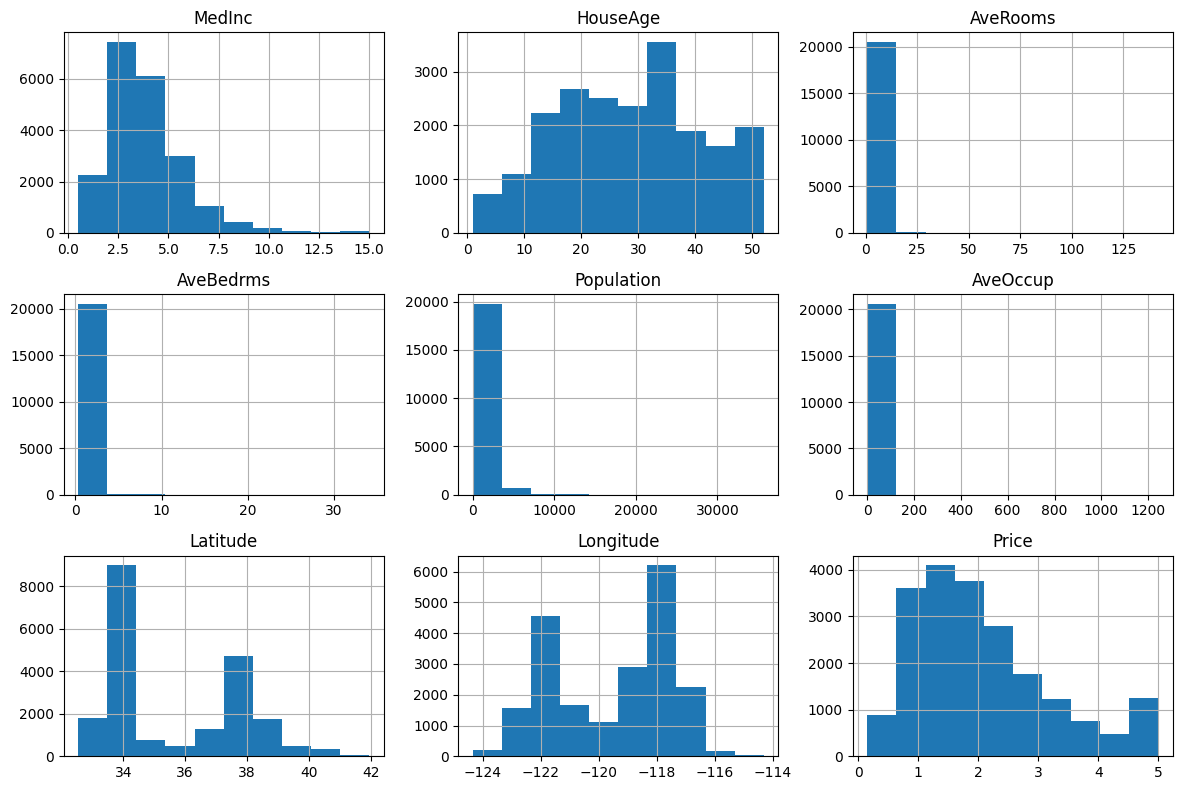

In [ ]:
df_original.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [ ]:
#Now lets see the correlation between each columns

In [ ]:
corr=df_original.corr()

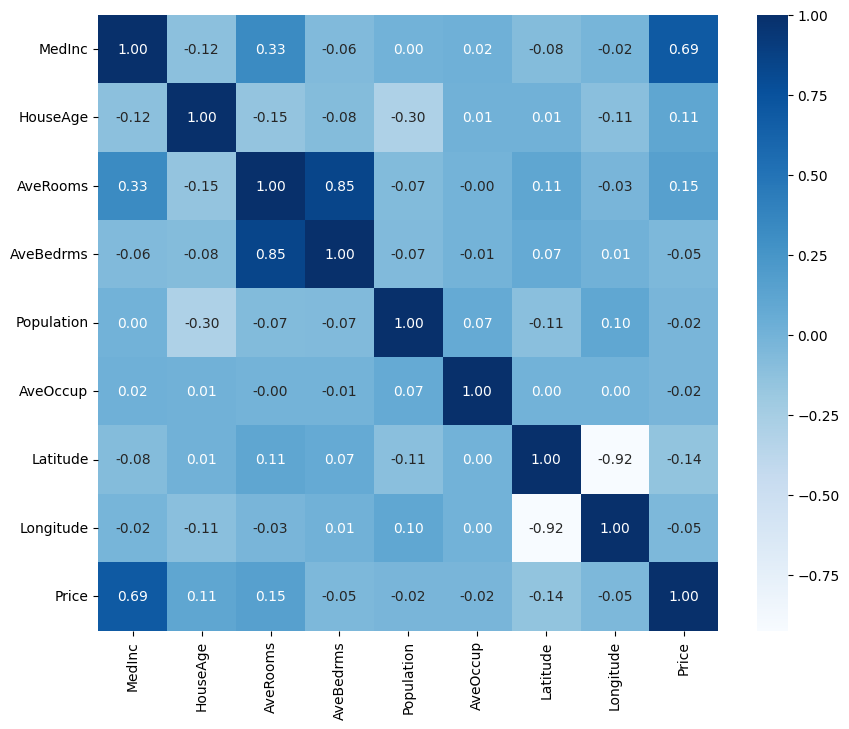

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    fmt='.2f',
    cmap='Blues',
    cbar=True,
    annot=True
)
plt.show()

 So, I am building two model

#first is

Original dataset
  
      ↓

Model without missing values

      ↓

Baseline performance

#and then:

Original dataset

      ↓

Introduce artificial missing values

      ↓

Handle missing values

      ↓

Same model

      ↓

Compare performance

In [ ]:
df_missing=df_original.drop("Price",axis=1)
df_missing

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
np.random.seed(100)
n = int(0.05 * len(df_missing) * len(df_missing.columns))
mask = np.zeros((len(df_missing), len(df_missing.columns)), dtype=bool)
indices = np.random.choice(mask.size, n, replace=False)
mask.flat[indices] = True
df_missing[mask] = np.nan

In [ ]:
df_missing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,NaN,6.281853,1.081081,565.0,2.181467,37.85,NaN


In [ ]:
df_missing['Price']=df_original['Price']

In [ ]:
df_missing.isnull().sum()

,0
MedInc,1049
HouseAge,1048
AveRooms,1029
AveBedrms,1015
Population,1017
AveOccup,1019
Latitude,1034
Longitude,1045
Price,0


Now we have two datsets df_original and df_missing so first lets handle the missing values in df_missing

Comparing original and null introduced data


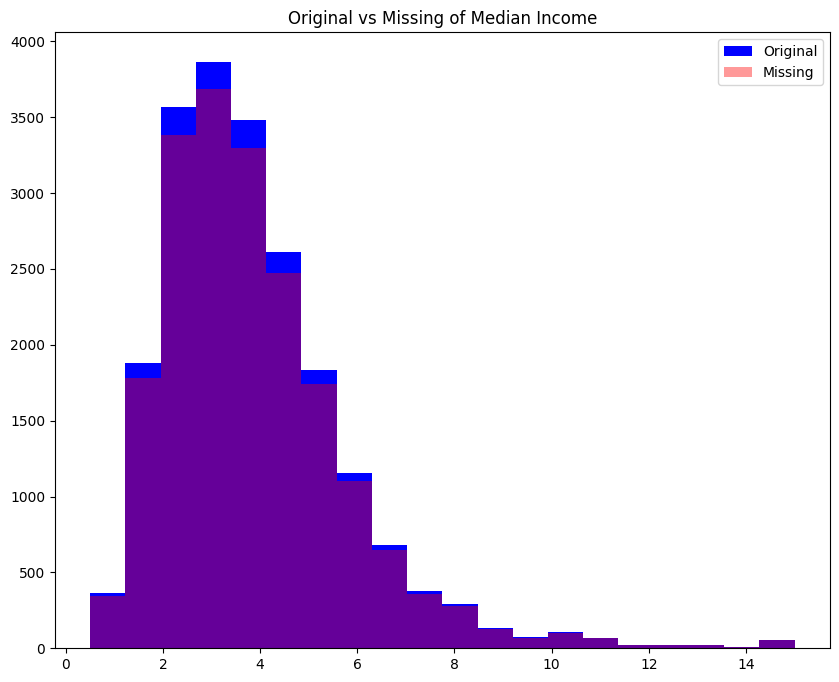

In [ ]:
plt.figure(figsize=(10,8))
plt.hist(
    df_original['MedInc'],
    label='Original',
    bins=20,
    alpha=1,
    color='blue'

)
plt.hist(
    df_missing['MedInc'],
    label='Missing',
    bins=20,
    alpha=0.4,
    color='red'
)
plt.title("Original vs Missing of Median Income")
plt.legend()
plt.show()

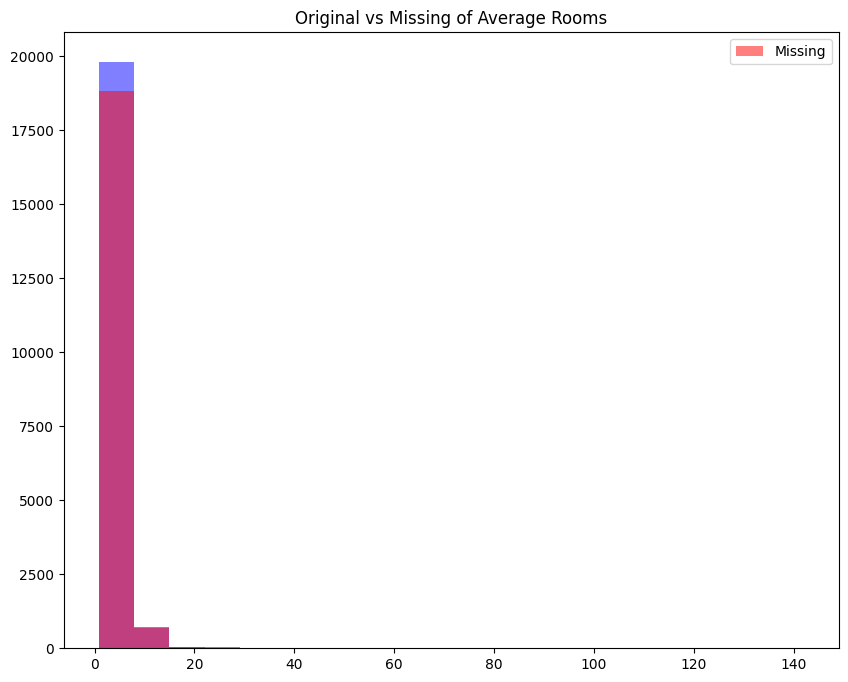

In [ ]:
plt.figure(figsize=(10,8))
plt.hist(
    df_original['AveRooms'],
    bins=20,
    alpha=0.5,
    color='blue'

)
plt.hist(
    df_missing['AveRooms'],
    label='Missing',
    bins=20,
    alpha=0.5,
    color='red'
)
plt.title("Original vs Missing of Average Rooms")
plt.legend()
plt.show()

In [ ]:
#Applying the imputers like mean/median and knn and comparing them
#applying them to the training data so that there would be no data leakage


What's data leakage?

Data leakage means data outside training data accidently gets used which gives the model an unfair advantage.
Ex:while calculating we use the data if testing also which is not in the case of real world

In [ ]:
from sklearn.model_selection import train_test_split
#For original data
x_train1,x_test1,y_train1,y_test1=train_test_split(df_original.drop("Price",axis=1),df_original["Price"],test_size=0.2,random_state=42)
#For missing data
x_train2,x_test2,y_train2,y_test2=train_test_split(df_missing.drop("Price",axis=1),df_missing["Price"],test_size=0.2,random_state=42)


Now handling the missing data

In [ ]:
#Mean Imputation
from sklearn.impute import SimpleImputer
imputer_mean=SimpleImputer(strategy="mean")

x_train2_imputed_mean=imputer_mean.fit_transform(x_train2)
x_test2_imputed_mean=imputer_mean.transform(x_test2)

In [ ]:
#Median Imputation
from sklearn.impute import SimpleImputer
imputer_median=SimpleImputer(strategy="median")

x_train2_imputed_median=imputer_median.fit_transform(x_train2)
x_test2_imputed_median=imputer_median.transform(x_test2)

In [ ]:
#KNN Imputation
from sklearn.impute import KNNImputer
imputer_knn=KNNImputer(n_neighbors=5)

x_train2_imputed_knn=imputer_knn.fit_transform(x_train2)
x_test2_imputed_knn=imputer_knn.transform(x_test2)

Lets compare them using histograms

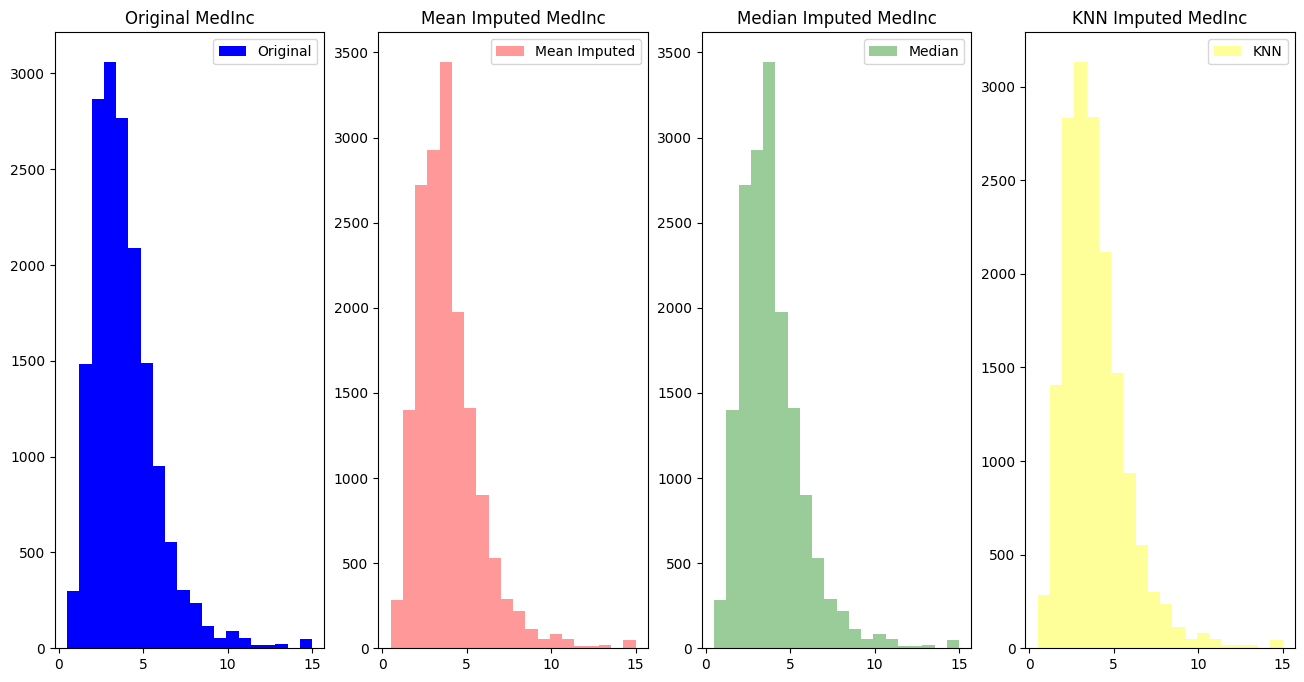

In [ ]:
plt.figure(figsize=(16,8))


plt.subplot( 1,4,1)
plt.hist(
    x_train1['MedInc'],
    label='Original',
    bins=20,
    alpha=1,
    color='blue'
     )
plt.title("Original MedInc")
plt.legend()


plt.subplot( 1,4,2)
plt.hist(
    x_train2_imputed_mean[:,0],
    label='Mean Imputed',
    bins=20,
    alpha=0.4,
    color='red'
)
plt.title("Mean Imputed MedInc")
plt.legend()


plt.subplot( 1,4,3)
plt.hist(
    x_train2_imputed_median[:,0],
    label='Median',
    bins=20,
    alpha=0.4,
    color='green'
)
plt.title("Median Imputed MedInc")
plt.legend()


plt.subplot( 1,4,4)
plt.hist(
    x_train2_imputed_knn[:,0],
    label='KNN',
    bins=20,
    alpha=0.4,
    color='yellow'
)
plt.title("KNN Imputed MedInc")
plt.legend()

plt.show()

# Modelling the data

In [ ]:
#Baseline Comparison of models
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score


In [ ]:
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor()
}


In [ ]:
results_original=[]
for name,model in models.items():
  model.fit(x_train1,y_train1)
  y_pred=model.predict(x_test1)
  results_original.append({
      "Model":name,
      "R2 Score":r2_score(y_test1,y_pred)
  })

In [ ]:
results_original

[{'Model': 'LinearRegression', 'R2 Score': 0.5757877060324508},
 {'Model': 'Lasso', 'R2 Score': 0.2841671821008396},
 {'Model': 'Ridge', 'R2 Score': 0.5758549611440127},
 {'Model': 'DecisionTreeRegressor', 'R2 Score': 0.6218215183278051},
 {'Model': 'RandomForestRegressor', 'R2 Score': 0.8043170860369162},
 {'Model': 'XGBRegressor', 'R2 Score': 0.8366589575055071}]

In [ ]:
#Do same for missing

In [ ]:
results_median=[]
for name,model in models.items():
  model.fit(x_train2_imputed_median,y_train2)
  y_pred=model.predict(x_test1)
  results_median.append({
      "Model":name,
      "R2 Score":r2_score(y_test1,y_pred)
  })

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
results_median

[{'Model': 'LinearRegression', 'R2 Score': 0.5680513828574423},
 {'Model': 'Lasso', 'R2 Score': 0.2591226277336528},
 {'Model': 'Ridge', 'R2 Score': 0.5680526859552565},
 {'Model': 'DecisionTreeRegressor', 'R2 Score': 0.5615722994940422},
 {'Model': 'RandomForestRegressor', 'R2 Score': 0.8005445147048285},
 {'Model': 'XGBRegressor', 'R2 Score': 0.8177665295090976}]

In [ ]:
results_knn=[]
for name,model in models.items():
  model.fit(x_train2_imputed_median,y_train2)
  y_pred_knn=model.predict(x_test1)
  results_knn.append({
      "Model":name,
      "R2 Score":r2_score(y_test1,y_pred_knn)
  })

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
results_knn_df=pd.DataFrame(results_knn)
results_knn_df.sort_values("R2 Score",ascending=False)


,Model,R2 Score
5,XGBRegressor,0.817767
4,RandomForestRegressor,0.799229
2,Ridge,0.568053
0,LinearRegression,0.568051
3,DecisionTreeRegressor,0.557838
1,Lasso,0.259123


In [ ]:
#Lets do Hyperparameter tuning

In [ ]:
searches={
    'Decision_Tree':(
        DecisionTreeRegressor(),
        {
        'max_depth':[None,5,10,15],
        'min_samples_split':[2,5,10,15],
        'min_samples_leaf':[1,2,5,10]

    }),

     'Random_Forest':(
        RandomForestRegressor(),
        {
         "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]

     }),
    'XGB':(
        XGBRegressor(),
        {

        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.1, 0.2]
    })
        }


In [ ]:
#Since there are many possibilities lets use RandomSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
tuned_models={}
tuned_results=[]
for name,(model,para) in searches.items():
  print(f"Tuning{name}..")

  search=RandomizedSearchCV(
      estimator=model,
      param_distributions=para,
      n_iter=5,
      cv=2,
      n_jobs=-1,

      random_state=42)
  search.fit(x_train2_imputed_knn,y_train2)
  tuned_models[name]=search.best_estimator_

  y_pred = search.predict(x_test2_imputed_knn)
  tuned_results.append({
      "Model":name,
      "Best Score":search.best_score_,
      "Best Params":search.best_params_,
      'Test_r2':r2_score(y_test2,y_pred)
  })


TuningDecision_Tree..
TuningRandom_Forest..
TuningXGB..


In [ ]:
tuned_result_df=pd.DataFrame(tuned_results)
tuned_result_df.sort_values("Test_r2", ascending=False)

,Model,Best Score,Best Params,Test_r2
2,XGB,0.774465,"{'n_estimators': 200, 'max_depth': 4, 'learnin...",0.776566
1,Random_Forest,0.752589,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.770553
0,Decision_Tree,0.642100,"{'min_samples_split': 2, 'min_samples_leaf': 1...",0.667502
